In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words = open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [83]:
# building the dataset
#splitting the dataset 
def build_dataset(words):

    block_size = 3 #how many chars we take to predict the next one
    X,Y = [],[]
    for w in words:
        # print(w)
        context=[0] * block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context),'---->',itos[ix])
            context = context[1:] + [ix] #crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*(len(words)))
n2 = int(0.9*(len(words)))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xts,Yts = build_dataset(words[n2:])



In [ ]:

C

tensor([[ 1.1173,  0.1499],
        [ 0.0036, -0.7434],
        [ 0.8303, -1.1424],
        [-1.6117, -0.3877],
        [-1.9874,  0.3936],
        [-0.6636,  0.8928],
        [-0.2531, -1.2446],
        [-0.2809, -0.5501],
        [ 0.1286, -1.9558],
        [-1.6454,  1.4428],
        [ 1.1575, -1.7370],
        [ 0.4678,  0.1359],
        [-1.6438, -0.4834],
        [ 0.3754,  0.9316],
        [ 0.8638, -0.3628],
        [ 2.2505, -1.1218],
        [ 1.0122, -0.7175],
        [-1.0118,  1.7386],
        [-0.5987, -0.4139],
        [-0.4483,  1.1735],
        [ 1.2527, -1.3853],
        [ 0.3756,  0.4428],
        [-0.4144, -1.2085],
        [-0.0308, -1.3778],
        [-1.7522, -0.3615],
        [-0.3623,  0.9416],
        [-1.4735, -1.1610]])

In [16]:
C[5]
X
C[X].shape

torch.Size([32, 3, 2])

In [ ]:
C[X] # X has 32 rows and 3 columns and and c has 27 rows and 2 columns , so the 32,3,2

tensor([[[-0.0646,  0.7294],
         [-0.0646,  0.7294],
         [-0.0646,  0.7294]],

        [[-0.0646,  0.7294],
         [-0.0646,  0.7294],
         [ 1.6658, -0.3958]],

        [[-0.0646,  0.7294],
         [ 1.6658, -0.3958],
         [-0.1526, -0.0564]],

        [[ 1.6658, -0.3958],
         [-0.1526, -0.0564],
         [-0.1526, -0.0564]],

        [[-0.1526, -0.0564],
         [-0.1526, -0.0564],
         [-0.9312, -0.0853]],

        [[-0.0646,  0.7294],
         [-0.0646,  0.7294],
         [-0.0646,  0.7294]],

        [[-0.0646,  0.7294],
         [-0.0646,  0.7294],
         [-1.5090,  1.0182]],

        [[-0.0646,  0.7294],
         [-1.5090,  1.0182],
         [ 0.1464, -1.0792]],

        [[-1.5090,  1.0182],
         [ 0.1464, -1.0792],
         [ 0.8181,  0.0144]],

        [[ 0.1464, -1.0792],
         [ 0.8181,  0.0144],
         [ 0.3321, -1.3581]],

        [[ 0.8181,  0.0144],
         [ 0.3321, -1.3581],
         [ 0.8181,  0.0144]],

        [[ 0.3321, -1

In [20]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([32, 6])

In [21]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([32, 6])

In [22]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [23]:
a.shape

torch.Size([18])

In [ ]:
a.view(3,3,2) # in this case view is much more efficient to use as compared to the above methods as we can use a single dimension array
# and view can change it to an n dimensional array without changing the memory map

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [25]:
emb.view(32,6)

tensor([[-0.0646,  0.7294, -0.0646,  0.7294, -0.0646,  0.7294],
        [-0.0646,  0.7294, -0.0646,  0.7294,  1.6658, -0.3958],
        [-0.0646,  0.7294,  1.6658, -0.3958, -0.1526, -0.0564],
        [ 1.6658, -0.3958, -0.1526, -0.0564, -0.1526, -0.0564],
        [-0.1526, -0.0564, -0.1526, -0.0564, -0.9312, -0.0853],
        [-0.0646,  0.7294, -0.0646,  0.7294, -0.0646,  0.7294],
        [-0.0646,  0.7294, -0.0646,  0.7294, -1.5090,  1.0182],
        [-0.0646,  0.7294, -1.5090,  1.0182,  0.1464, -1.0792],
        [-1.5090,  1.0182,  0.1464, -1.0792,  0.8181,  0.0144],
        [ 0.1464, -1.0792,  0.8181,  0.0144,  0.3321, -1.3581],
        [ 0.8181,  0.0144,  0.3321, -1.3581,  0.8181,  0.0144],
        [ 0.3321, -1.3581,  0.8181,  0.0144, -0.9312, -0.0853],
        [-0.0646,  0.7294, -0.0646,  0.7294, -0.0646,  0.7294],
        [-0.0646,  0.7294, -0.0646,  0.7294, -0.9312, -0.0853],
        [-0.0646,  0.7294, -0.9312, -0.0853,  0.3321, -1.3581],
        [-0.9312, -0.0853,  0.3321, -1.3

# Forward Pass

In [ ]:

h

tensor([[ 0.0782, -0.7807, -0.8862,  ..., -0.4971, -0.9281, -0.6243],
        [-0.9193, -0.9994, -0.6660,  ..., -0.7391, -0.9981,  0.9978],
        [ 0.6971,  0.9703, -0.5097,  ...,  0.4957,  0.1051,  0.3697],
        ...,
        [ 0.8328,  0.5541, -0.1758,  ...,  0.9908, -0.9716,  0.9657],
        [-0.8916, -0.9367, -0.6427,  ..., -0.9915, -0.0445,  0.3991],
        [ 0.6438,  0.9821, -0.8035,  ..., -0.0067,  0.4430, -0.9654]])

In [28]:
h.shape

torch.Size([32, 100])

In [128]:
C = torch.randn((27,10))
W1 = torch.randn((30,200))
b1 = torch.randn(200)
W2 = torch.randn((200,27))
b2 = torch.randn(27)
parameters = [C,W1,b1,W2,b2]
for p in parameters:
    p.requires_grad = True


In [ ]:
# counts = logits.exp()
# probs = counts/counts.sum(1,keepdims=True)
# probs.shape
# loss = -probs[torch.arange(32),Y].log().mean()
# loss


tensor(16.6633)

In [129]:
lossi = []
stepi = []

# Backward Pass

In [138]:

for i in range(50000):
    ix = torch.randint(0,Xtr.shape[0],(32,))
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])
    


    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    #update
    for p in parameters:
        p.data += -0.01*p.grad

    lossi.append(loss.log10().item())
    stepi.append(i)

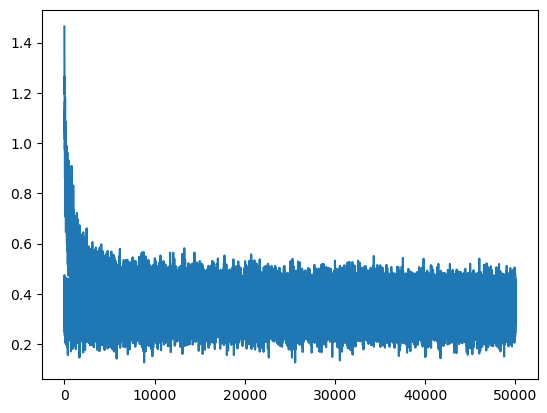

In [139]:
plt.plot(stepi,lossi)

In [140]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ytr)
loss.item()

2.1626176834106445

In [141]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss.item()

2.186032295227051

In [110]:
emb = C[Xts]
h = torch.tanh(emb.view(-1,6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits,Yts)
loss.item()

2.343489408493042

In [ ]:
# spliting data into three parts 
# training split, dev/validation split , test split
# 80 , 10 , 10
#validation split is majorly used to train or adjust the hyperparameters


In [143]:
#sampling from the neural net
block_size = 3 
for _ in range(20):
    out =[]
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = torch.softmax(logits,dim=1)
        ix = torch.multinomial(probs,num_samples=1).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))    


hendelie.
prensza.
semeri.
begh.
ievanna.
karahabeck.
breyana.
niha.
degolie.
kai.
xim.
mariah.
ang.
zakah.
einella.
rosessavan.
kaith.
briel.
sha.
chimayin.
